¡Bienvenidos a la segunda parte de la Clase 1 de la *Quantum Jam 2025*! Para ejecutar el código de los ejercicios y ejemplos de esta clase, corran la siguiente celda:

In [ ]:
!pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer qiskit_qasm3_import

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_bloch_vector, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter, ParameterVector
import qiskit.qasm3
from qiskit_ibm_runtime.fake_provider import FakeVigoV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, EstimatorV2 as Estimator, QiskitRuntimeService

# Mediciones y observables

## Operadores hermíticos

Los **operadores hermíticos** son operadores lineales cuyo conjugado hermítico es igual al mismo operador; es decir, se cumple que ${\hat{A}}^\dagger=\hat{A}$. Si tomamos su representación matricial $A$, vemos que se cumplen dos importantes propiedades (sin importar la base que elijamos para construir la matriz):

- *Sus autovalores son reales.* Recordemos que los autovalores $\lambda_i$ de una matriz se obtienen resolviendo la ecuación $\left|A-\lambda I\right|=0$, donde $I$ es la matriz identidad.

- *Sus autovectores son ortogonales entre sí.* Podemos obtener el autovector $|\phi_i\rangle$ asociado a cada autovalor $\lambda_i$ resolviendo la ecuación matricial $\left(A-\lambda_iI\right)|\phi_i\rangle=\vec{0}$.

## Observables

En mecánica cuántica, las magnitudes físicas que podemos medir (como la posición, la cantidad de movimiento, el spin o el momento angular) se denominan **observables**. Cada observable $\mathcal{A}$ se describe mediante un operador hermítico $\hat{A}$. Al medir el observable $\mathcal{A}$, obtendremos como resultado los autovalores del operador hermítico.

El espectro de autovalores del operador puede ser tanto continuo como discreto. Si es discreto, puede ser tanto finito como infinito. Si el espectro de autovalores es discreto, diremos que el observable está **cuantizado**.

**Ejemplo:** una propiedad de ciertas partículas es el spin. Cuando medimos el spin de un [fermión](https://es.wikipedia.org/wiki/Fermi%C3%B3n#:~:text=Un%20fermi%C3%B3n%20es%20uno%20de,principio%20de%20exclusi%C3%B3n%20de%20Pauli.) a lo largo de una dirección cualquiera, obtenemos uno de dos valores posibles. Supongamos que esa dirección se llama "eje $z$". El observable que representa la proyección del spin sobre el eje $z$ es $\mathcal{S}_z$, y su operador hermítico $\hat{S}_z$ tiene la siguiente representación matricial:

\begin{equation}
S_z=\frac{\hbar}{2}\begin{bmatrix}1 & 0 \\ 0 & -1 \end{bmatrix}
\end{equation}

donde $\hbar$ es una [constante física](https://es.wikipedia.org/wiki/Constante_de_Planck).
Los dos resultados posibles que obtendremos al medir son los autovalores de la matriz: $+\frac{\hbar}{2}$ (asociado al autoestado/autovector conocido como "spin up") y $-\frac{\hbar}{2}$ (asociado al autoestado "spin down").

## Proyectores

Un grupo importante de operadores hermíticos son los *operadores de proyección*, o **proyectores**. Si aplicamos un proyector $\hat{P}_{|\varphi\rangle}=|\varphi\rangle\langle\varphi|$ al ket $|\pi\rangle$, obtenemos la *proyección ortogonal* de $|\pi\rangle$ sobre el *subespacio* generado por $|\varphi\rangle$.

Los proyectores satisfacen la igualdad $\hat{P}^2=\hat{P}$. Esto quiere decir que si aplicamos un proyector dos veces, obtendremos el mismo resultado que al aplicarlo una sola vez.

Geométricamente, la imagen debajo muestra cómo actúa un proyector sobre un ket. Al aplicar $\hat{P}_{|\varphi\rangle}$ a $|\pi\rangle$ (el vector azul), el ket "se proyecta" hacia el plano o espacio "en el que vive" $|\varphi\rangle$ (el vector negro). El resultado será el vector rosado: $\hat{P}_{|\varphi\rangle}|\pi\rangle=|\varphi\rangle\langle\varphi|\pi\rangle=z|\varphi\rangle$, donde $\langle\varphi|\pi\rangle=z\in\mathbb{C}$. La proyección da como resultado el ket $|\varphi\rangle$ mutliplicado por un número $z$. Nótese que el vector resultante no necesariamente está normalizado.

<img src="https://i.imgur.com/D4agAGM.jpeg" align="center"/>

En general, podemos armar un operador de proyección sumando proyecciones ortogonales. El resultado será un operador que, al aplicarlo a un ket, lo proyecte al subespacio generado por el conjunto de las proyecciones individuales:

\begin{equation}
\hat{P}_m=\sum_{i=1}^m|\phi_i\rangle\langle\phi_i|
\end{equation}

## Mediciones

Cada par de autovalor y autovector de un operador hermítico cumple la famosa ecuación de autovalores y autovectores:

\begin{equation}
\hat{A}|\phi_i\rangle=\lambda_i|\phi_i\rangle
\end{equation}

En el caso de que cada autovalor esté asociado a un único autovector, podemos saber cuál es la probabilidad de medir el autovalor $\lambda_i$ en el sistema representado por el estado $|\psi\rangle$ mediante la siguiente ecuación:

\begin{equation}
P(\lambda_i)=\left|\langle\phi_i|\psi\rangle\right|^2
\end{equation}

En el caso de que un autovalor $\lambda_j$ sea compartido por muchos autovectores (de manera tal que cada uno cumpla por su cuenta con la ecuación de autovalores y autovectores), estamos ante un problema **degenerado**: no podemos distinguir un único autovector o **autoestado** al medir el autovalor. Si un autovalor tiene asociados $m$ autovectores, decimos que el problema es *m-degenerado*, siendo $m$ el grado de degeneración.

Para los problemas degenerados, la probabilidad de medir el autovalor $\lambda_j$ en un sistema en el estado $|\psi⟩$ está dada por:

\begin{equation}
P(\lambda_j)=\langle\psi|\hat{P}_m|\psi\rangle
\end{equation}

donde $\hat{P}_m$ es el proyector generado por todos los autovectores asociados al autovalor $\lambda_j$:

\begin{equation}
\hat{P}_m=|\phi_{j1}\rangle\langle\phi_{j1}|+|\phi_{j2}\rangle\langle\phi_{j2}|+\cdots+|\phi_{jm}\rangle\langle\phi_{jm}|
\end{equation}

¿Cuál será el estado del sistema después de medir? Luego de realizar una medición, el ket *colapsa* al estado $|\psi'\rangle$, que está dado por la siguiente ecuación:

\begin{equation}
|\psi'\rangle= \frac{\hat{P}_i|\psi\rangle}{\sqrt{P(\lambda_i)}}
\end{equation}

Para el caso no degenerado, $\hat{P}_i=|\phi_i\rangle\langle\phi_i|$.

Dicho en palabras (aunque para algunas personas pueda traer más confusión que esclarecimiento), el estado después de medir será la proyección ortogonal al subespacio asociado al autovalor que se midió, después de normalizarlo.

### Ejercicio 11: proyectando qubits

a. Crea el proyector $\hat{P}_0$ asociado al estado $|\psi_0\rangle=\frac{i}{\sqrt{3}}|0\rangle+\sqrt{\frac{2}{3}}|1\rangle$ y verifica que cumple con las ecuaciones $\hat{P}^2=\hat{P}$ (por ser un proyector) y $\hat{P}^\dagger=\hat{P}$ (por ser un operador hermítico).

b. Proyecta el estado $|\psi_1\rangle=\frac{2}{\sqrt{5}}|0\rangle+\frac{i}{\sqrt{5}}|1\rangle$ al subespacio generado por $|\psi_0\rangle$.

In [ ]:
#Escriba su código aquí para la parte a


In [ ]:
#Escriba su código aquí para la parte b


### Ejercicio 12: condición de clausura

La representación matricial del operador identidad es:

\begin{equation}
I=\begin{bmatrix}
1 & 0 & \cdots & 0 \\
0 & 1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & 1
\end{bmatrix}
\end{equation}

Dada una base ortonormal $\left\{|u_1\rangle,\ldots ,|u_n\rangle\right\}$, podemos expresar el operador identidad como:

\begin{equation}
\hat{I}=\sum_{i=0}^n|u_i\rangle\langle u_i|
\end{equation}

Esta expresión se denomina **condición de clausura**. Cada término de la suma puede pensarse como un proyector $\hat{P}_i$ (al subespacio generado por $|u_i\rangle$), en donde todos los proyectores son ortogonales entre sí: $\hat{P}_i\cdot\hat{P}_j=\vec{0}$ para $i\neq j$.

Teniendo esto en cuenta, obtén el operador identidad a partir de las bases $\left\{|0\rangle,|1\rangle\right\}$, $\left\{|+\rangle,|-\rangle\right\}$ y $\left\{|i\rangle,|-i\rangle\right\}$.

In [ ]:
# Escriba su solución aquí


### Ejercicio 13: el teorema de descomposición espectral

Podemos obtener los autovalores $\lambda_i$ y sus autovectores asociados $|\phi_i\rangle$ de un operador lineal $\hat{A}$. Cada par cumplirá con la ecuación $\hat{A}|\phi_i\rangle=\lambda_i|\phi_i\rangle$.

El **teorema de descomposición espectral** dice que podemos expresar al operador lineal de la siguiente manera:

\begin{equation}
\hat{A}=\sum_i\lambda_i|\phi_i\rangle\langle\phi_i|
\end{equation}

Verifica que se cumple el teorema de descomposición espectral para los operadores de Pauli (ver el ejercicio 9), obteniendo los autovectores y autovalores de sus representaciones matriciales.

In [ ]:
# Escriba su solución aquí


### Ejercicio 14: valores medios

El **valor medio** - también conocido como *media*, *valor esperado* o *esperanza* - de un observable $\mathcal{A}$ en un estado $|\psi\rangle$ está dado por:

\begin{equation}
\langle\hat{A}\rangle=\langle\psi|\hat{A}|\psi\rangle
\end{equation}

Obtén los valores esperados de los operadores de Pauli y la compuerta de Hadamard (ver los ejercicios 9 y 10) para los estados $|0\rangle$, $|1\rangle$, $|+\rangle$, $|-\rangle$, $|i\rangle$ y $|-i\rangle$.

In [ ]:
# Escriba su solución aquí


### Ejercicio 15: midiendo qubits

Aplica la compuerta de Hadamard, $\hat{H}$, al estado $|\psi_0\rangle=\frac{i}{\sqrt{3}}|0\rangle+\sqrt{\frac{2}{3}}|1\rangle$ y muestra en la terminal el estado $|\psi_0'\rangle=\hat{H}|\psi_0\rangle$ (este estado ya está normalizado, por lo que es un qubit válido). Observa el cambio de probabilidades de obtener cada estado de la base computacional al medir $|\psi_0'\rangle$.

In [ ]:
# Escribe tu solución aquí


# Evolución temporal

## Operadores unitarios

Un **operador unitario** $\hat{U}$ es un operador que cumple las ecuaciones $\hat{U}\hat{U}^\dagger=\hat{U}^\dagger\hat{U}=\hat{I}$, donde $\hat{I}$ es el *operador identidad*, que deja intacto al vector al que se lo aplica: $\hat{I}|\psi\rangle=|\psi\rangle$. Por lo tanto, si le aplicamos un operador unitario a un qubit y luego le aplicamos su operador adjunto (o viceversa), obtendremos el qubit original.

## Evolución en el tiempo

Los operadores unitarios nos sirven para describir la evolución temporal de los sistemas cuánticos. Supongamos que $|\psi\rangle$ es el ket de estado de un sistema cerrado en un tiempo $t_1$, y que $|\psi'\rangle$ es el ket de estado del sistema en el tiempo $t_2>t_1$. Podemos obtener $|\psi'\rangle$ a partir de cierta transformación unitaria $\hat{U}$:

\begin{equation}
|\psi'\rangle=\hat{U}|\psi\rangle
\end{equation}

<img src="https://upload.wikimedia.org/wikipedia/commons/2/2e/Erwin_Schr%C3%B6dinger_%281933%29.jpg" align="right" width="150" />

**Nota:** la transformación unitaria $\hat{U}$ relaciona el estado de un sistema cerrado en dos momentos específicos. Para saber cómo evoluciona un sistema cerrado en *tiempo continuo*, se utiliza la **ecuación de Schrödinger**:

\begin{equation}
i\hbar\frac{d|\psi\rangle}{dt}=\hat{H}|\psi\rangle
\end{equation}

donde $\hbar$ es la *constante de Planck reducida* y $\hat{H}$ es un operador hermítico conocido como el **Hamiltoniano** del sistema. Esta ecuación, desarrollada por el físico Erwin Schrödinger en 1925 (ver su imagen a la derecha), es una de las más importantes de la mecánica cuántica.

### Ejercicio 16: conservación de la norma

Los operadores unitarios $\hat{U}$ preservan la norma de los kets; es decir, se cumple que $||\hat{U}|\psi\rangle||=|||\psi\rangle||$.

Comprueba esta propiedad creando el operador unitario con la siguiente representación matricial (en la base computacional):

\begin{equation}
U_1=\frac{1}{\sqrt2}\begin{bmatrix} 1 & i \\ i & 1 \end{bmatrix}
\end{equation}

Luego, aplícalo al ket $|+\rangle$ y verifica que su norma siga siendo unitaria.

In [ ]:
#Escriba su solución aquí


### Ejercicio 17: multiplicando operadores unitarios

El producto de dos operadores unitarios da como resultado otro operador unitario.

Comprueba esta propiedad creando el operador $\hat{U}_3=\hat{U}_1\cdot\hat{U}_2$, donde $\hat{U}_1$ es el operador del ejercicio anterior y $\hat{U}_2=\frac{\sqrt3}{2}|0\rangle\langle0|-\frac{1}{2}e^{-i\frac{\pi}{7}}|0\rangle\langle1|+\frac{1}{2}e^{i\frac{\pi}{5}}|1\rangle\langle0|+\frac{\sqrt3}{2}e^{i\left(\frac{\pi}{5}-\frac{\pi}{7}\right)}|1\rangle\langle1|$. Verifica que $\hat{U}_3^\dagger\hat{U}_3=\hat{I}$.

In [ ]:
#Escriba su solución aquí


### Ejercicio 18: creando bases

Dada una base ortonormal $\left\{|u_1\rangle,\ldots,|u_n\rangle\right\}$, podemos obtener otra base ortonormal  $\left\{|w_1\rangle,\ldots,|w_n\rangle\right\}$ multiplicando cada vector por un operador unitario: $|w_i\rangle=\hat{U}|u_i\rangle$.

Obtén una base a partir la base computacional y el operador $\hat{U}_2$ del ejercicio anterior. Comprueba que la nueva base sea ortonormal.

In [ ]:
#Escriba su solución aquí


### Ejercicio 19: operadores famosos

Comprueba que los operadores $X$, $Y$, $Z$ y $H$ (ver ejercicios 9 y 10) son unitarios. Investiga sobre los operadores $S$ y $T$, observa el efecto que tienen sobre los estados de la base computacional y verifica que sean operadores unitarios.

In [ ]:
# Escriba su solución aquí


# Fases y esferas

## Fase global

Supongamos que tenemos un estado $|\psi\rangle$ y otro estado $|\pi\rangle$ que difiere de $|\psi\rangle$ solo por un número complejo de módulo unitario $e^{i\theta}$:

\begin{equation}
|\pi\rangle=e^{i\theta}|\psi\rangle
\end{equation}

Este número complejo se conoce como **fase global**.

El estado $|\pi\rangle$ también estará normalizado, ya que $\langle\pi|\pi\rangle=\langle\psi|e^{-i\theta}e^{i\theta}|\psi\rangle=\langle\psi|\psi\rangle=1$.

En la "Nota 2" de la sección **Kets y qubits** vimos que la función de onda $|\psi\rangle$ de un sistema cuántico no tiene un significado físico, sino que la utilizamos para conocer las *probabilidades* de obtener cierto resultado al medir el sistema. Se puede demostrar que la probabilidad de obtener un resultado al medir el sistema $|\pi\rangle$ es igual a la del sistema $|\psi\rangle$:

\begin{equation}
P_{|\pi\rangle}(\lambda_i)=\left|\langle\phi_i|\pi\rangle\right|^2=\left|e^{i\theta}\right|^2\left|\langle\phi_i|\psi\rangle\right|^2=\left|\langle\phi_i|\psi\rangle\right|^2=P_{|\psi\rangle}(\lambda_i)
\end{equation}

Acá, mostramos que son equivalentes para el caso de un autovalor no degenerado, pero ustedes pueden demostrarlo para un autovalor degenerado.

En conclusión, dos estados que difieren únicamente por una fase global son *físicamente indistinguibles*: representan el mismo sistema. Siempre que tengamos una fase global (un complejo de módulo unitario) que podamos sacar como factor común de la expresión matemática del qubit, podemos ignorarla y no escribirla.

## Fase relativa

Para un qubit $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$, dijimos que $\alpha$ y $\beta$ son números complejos. Por lo tanto, tienen un módulo y una fase:

\begin{equation}
\alpha=|\alpha|e^{i\theta_\alpha}
\qquad
\beta=|\beta|e^{i\theta_\beta}
\end{equation}

Reemplazando en la expresión del qubit, tenemos que:

\begin{equation}
|\psi\rangle=|\alpha|e^{i\theta_\alpha}|0\rangle+|\beta|e^{i\theta_\beta}|1\rangle=e^{i\theta_\alpha}\left(|\alpha||0\rangle+|\beta|e^{i(\theta_\beta-\theta_\alpha)}|1\rangle\right)
\end{equation}

Despreciando la fase global $e^{i\theta_\alpha}$, vemos que $|1\rangle$ tiene una **fase relativa** de $e^{i(\theta_\beta-\theta_\alpha)}$ respecto al ket $|0\rangle$. A diferencia de la fase global, esta fase relativa sí tiene importancia física y no puede ser ignorada.

**Ejemplo:** los estados $|+\rangle$ y $|-\rangle$ difieren por una fase global de $180^\circ=\pi$ radianes.

\begin{equation}
\left|+\right>=\frac{\left|0\right>+\left|1\right>}{\sqrt{2}}
\qquad\qquad
\left|-\right>=\frac{\left|0\right>-\left|1\right>}{\sqrt{2}}=\frac{\left|0\right>+e^{i\pi}\left|1\right>}{\sqrt{2}}
\end{equation}

Como muestran los resultados del ejercicio 10, aplicar la compuerta de Hadamard al qubit $|+\rangle$ devuelve el estado $|0\rangle$ (tendremos un $100\%$ de probabilidad de medir $0$) y aplicarla al qubit $|-\rangle$ retorna el estado $|1\rangle$ (mediremos $1$ con un $100\%$ de probabilidad). Debido a la fase relativa, los resultados que obtendremos al medir después de aplicar la compuerta serán completamente distintos.

## La esfera de Bloch

<img src="https://upload.wikimedia.org/wikipedia/commons/0/0b/Felix_Bloch%2C_Stanford_University.jpg" align="right" width="130" />

Existe una manera muy intuitiva y cómoda de graficar qubits: la **esfera de Bloch**, llamada así en honor al físico Felix Bloch (ver su imagen a la derecha). Aquí, hablaremos de cómo representar en esta esfera el tipo de qubits que estuvimos viendo en la clase, denominados **estados puros**.

La esfera de Bloch es una esfera de radio unitario en un espacio tridimensional. Pueden graficarla en Qiskit corriendo las siguientes líneas:





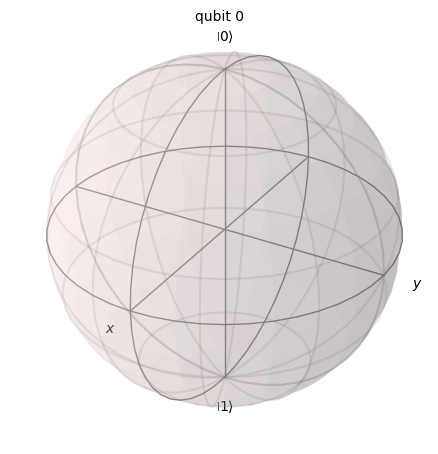

In [ ]:
null_state = Statevector([0, 0])
plot_bloch_multivector(null_state)

#Otra forma:
#plot_bloch_vector([0,0,0]) #Vector [x, y, z]

Como pueden ver, representamos los estados $|0\rangle$ y $|1\rangle$ en el eje $z$: $|0\rangle$ se encuentra en $+1\hat{z}$, y $|1\rangle$ en $-1\hat{z}$. Todos los estados puros se representan *en la superficie* de la esfera, ya que tienen norma unitaria (están normalizados).

Grafiquemos los vectores correspondientes a los estados $|0\rangle$ y $|1\rangle$ en la esfera de Bloch:

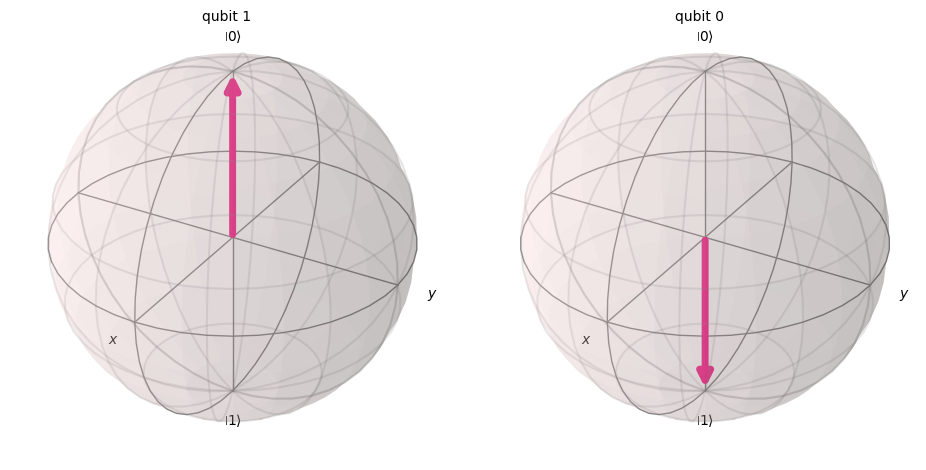

In [ ]:
#Estado |0>|1> en la base computacional de 2 qubits: {|00>, |01>, |10>, |11>}
computational_basis = Statevector.from_label('01')

#Otra forma:
#computational_basis = Statevector([0, 1, 0, 0])

plot_bloch_multivector(computational_basis, reverse_bits = True)

El vector graficado en rosado representa al qubit. Al graficar cualquier qubit $|\psi\rangle$ en la esfera de Bloch, veremos que tendremos una mayor probabilidad de medir $1$ si está más cerca de $|1\rangle$ ($-1\hat{z}$), y $0$ si está más cerca de $|0\rangle$ ($+1\hat{z}$).

Si el qubit se encuentra en el plano $xy$, tendremos la misma probabilidad de medir $0$ que de medir $1$. Algunos ejemplos de qubits que muestran este comportamiento son los estados $|+\rangle$ y $|-\rangle$ (que se encuentran sobre el eje $x$), y $|i\rangle$ y $|-i\rangle$ (en el eje $y$):  

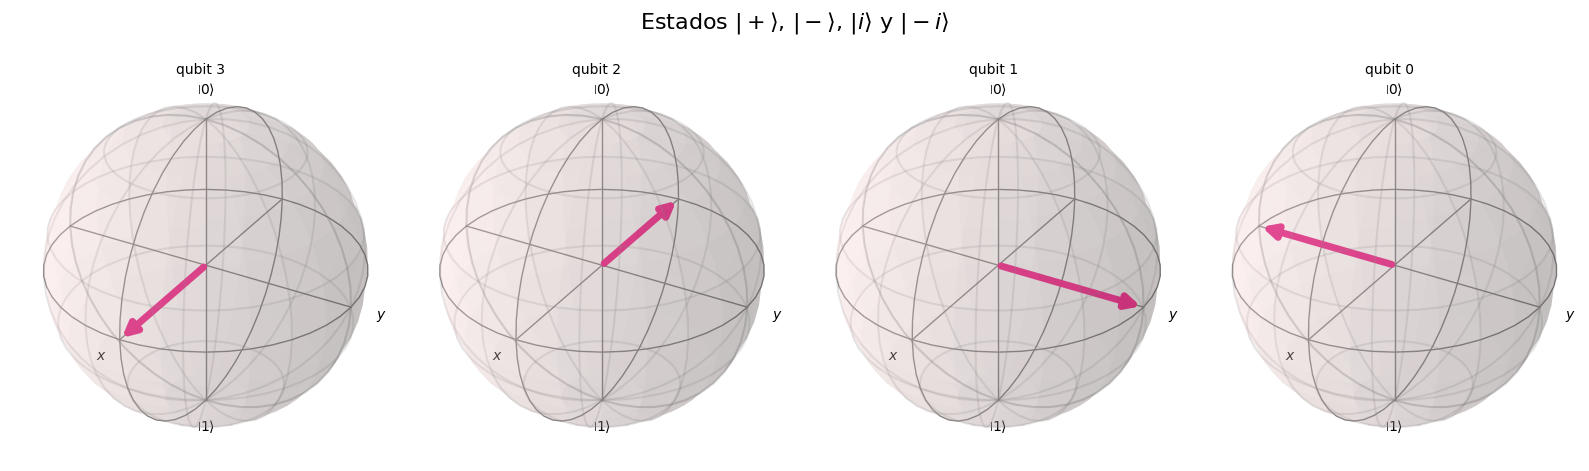

In [ ]:
plot_bloch_multivector(Statevector.from_label('+-rl'), reverse_bits = True,
                       title = r"Estados $|+\rangle$, $|-\rangle$, $|i\rangle$ y $|-i\rangle$")

En computación cuántica, podemos hablar de operaciones reversibles e irreversibles. Las *operaciones reversibles* son las representadas por matrices unitarias $\hat{U}$; es decir, representan una evolución en el tiempo. No nos hacen perder información que contenga el qubit. Podemos pensar a las operaciones reversibles como transformaciones que "mueven" al qubit sobre la superficie de la esfera de Bloch.

Las *operaciones irreversibles* nos hacen perder definitivamente información que contiene el qubit. Las mediciones son operaciones irreversibles, ya que extraigo algo de información a costa de perder el resto: no puedo saber las amplitudes de probabilidad $\alpha$ y $\beta$ con una sola medición. Si quisiera averiguar las amplitudes, debería preparar una muestra grande de qubits idénticos y obtener los valores de $\alpha$ y $\beta$ estadísticamente. Medir respecto a los estados de la base computacional generan que el qubit colapse irreversiblemente hacia el eje $z$ en la superficie de la esfera de Bloch.

<img src="https://upload.wikimedia.org/wikipedia/commons/6/6b/Bloch_sphere.svg" align="right" width="250" />

**Nota 1:** podemos mapear cada punto $(x, y, z)$ de la esfera de Bloch a un qubit de la forma $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle=|\alpha||0\rangle+|\beta|e^{i(\theta_\beta-\theta_\alpha)}|1\rangle$ utilizando las *coordenadas esféricas* $\rho$, $\varphi$ y  $\theta$, donde:

- $\rho$ representa la distancia al origen $(0, 0, 0)$;

- $\varphi$ representa el ángulo respecto al eje $x$ (usando la regla de la mano derecha; es decir, apuntando con el pulgar al eje $z$ y enrollando el resto de los dedos en la dirección del ángulo). $\varphi$ puede valer de $0$ a $2\pi$ radianes;

- $\theta$ representa el ángulo repecto al eje $z$, y va de $0$ a $\pi$ radianes.



Como la esfera de Bloch es unitaria, $\rho=1$. Por lo tanto, el vector $\vec{r}$ que representa al qubit en la esfera es:

\begin{equation}
\vec{r}=(x,y,z)=(\sin(\theta)\cos(\varphi), sin(\theta)cos(\varphi), cos(\theta))
\end{equation}

La expresión del qubit dados $\varphi$ y $\theta$ está dada por:

\begin{equation}
|\psi\rangle=\cos\left(\frac{\theta}{2}\right)|0\rangle+\cos\left(\frac{\theta}{2}\right)e^{i\varphi}|1\rangle
\end{equation}

**Nota 2:** dijimos que representaremos estados puros sobre la superficie de la esfera de Bloch. Este tipo de estados son los que podemos representar matemáticamente con un vector columna (ket), como definimos - de manera informal - en esta clase. Existe otra forma más general de representar estados, utilizando otra manera de representar el formalismo de la mecánica cuántica: el **operador densidad**. Para la definición formal de información cuántica, es necesario usar este formalismo.

Para un estado puro $|\psi\rangle$, podemos obtener su operador densidad como $\rho=|\psi\rangle\langle\psi|$ (nótese que es un proyector).

Existen otros estados, llamados **estados mezcla**, que solo pueden representarse mediante el operador densidad.La descripción de estos estados está por fuera del alcance de esta clase, pero ofrecemos un breve puntapié por si deciden investigar más sobre este tema.

Los estados mezcla (o estados mixtos) pueden obtenerse a través de una mezcla estadística. Supongamos que preparamos un sistema cuántico de manera tal que podemos obtener un estado $|\psi_k\rangle$ con una probabilidad $p_k$. Si tenemos $N$ estados posibles, las probabilidades $p_k$ deben sumar uno ($p_1+p_2+\cdots+p_N=1$). Podemos pensar a cada $p_k$ como una "probabilidad clásica", a diferencia de las amplitudes de probabilidad de la superposición de estados. El operador densidad que representa al sistema es:

\begin{equation}
\rho=\sum_{k=1}^Np_k|\psi_k\rangle\langle\psi_k|
\end{equation}

En la esfera de Bloch, los estados mezcla no se representan en la superficie, sino que se grafican *en el interior* de la esfera (no están normalizados). Un estado en el origen de la esfera representa un sistema con incerteza máxima: en el lenguaje de la *teoría de la información*, su *entropía* es máxima.

Otra manera de obtener estados mezcla es tomando un solo qubit de un sistema *entrelazado*. Veremos qué es el entrelazamiento en la próxima clase.



## Los operadores de Pauli

Vimos que cada eje cartesiano está relacionado con distintos estados:
- En el eje $x$, encontramos a los estados $|+\rangle$ y $|-\rangle$;
- En el eje $y$, encontramos a los estados $|i\rangle$ y $|-i\rangle$;
- En el eje $z$, encontramos a los estados $|0\rangle$ y $|1\rangle$.

<img src="https://upload.wikimedia.org/wikipedia/commons/e/ea/Wolfgang_Pauli.jpg" align="right" width="200" />

Cada uno de estos pares de estados forman una base ortonormal para los qubits, y son los autovectores de tres operadores distintos y muy importantes: los operadores de Pauli, llamados así en honor al físico Wolfgang Pauli (ver su imagen a la derecha). Dichos operadores tienen su propia representación matricial en la base computacional, como se puede ver en el ejercicio 9. En notación de Dirac y utilizando el teorema de descomposición espectral (ver el ejercicio 13), podemos expresar a los operadores como sumas y restas de productos externos:

\begin{align}
\hat{X}=\hat\sigma_x=&|+\rangle\langle+|-|-\rangle\langle-|=|0\rangle\langle1|+|1\rangle\langle0|
\\
\hat{Y}=\hat\sigma_y=&|i\rangle\langle i|-|-i\rangle\langle-i|=i|1\rangle\langle0|-i|0\rangle\langle1|
\\
\hat{Z}=\hat\sigma_z=&|0\rangle\langle0|-|1\rangle\langle1|
\end{align}

Los operadores de Pauli son unitarios, por lo que representan transformaciones del estado de los qubits. En la esfera de Bloch, los operadores $\hat{X}$, $\hat{Y}$ y $\hat{Z}$ representan rotaciones de $180^\circ$ alrededor de los ejes $x$, $y$ y $z$ respectivamente (utilizando la regla de la mano derecha).

Además, son operadores hermíticos y cada uno representa un observable. Físicamente, representan las componentes del spin de ciertas partículas conocidas como *fermiones* ("partículas de spin 1/2"). También se utilizan para caracterizar a los polarizadores en el modelo cuántico de la polarización de fotones (horizontal, vertical, diagonal, antidiagonal, circular derecha o circular izquierda).

**Nota:** para estados mezcla (ver la "Nota 2" en la sección "La esfera de Bloch"), podemos vincular el operador densidad de un qubit con la esfera de Bloch y los operadores de Pauli. Sean $I$ la matriz identidad, $\vec{r}=(r_x, r_y, r_z)$ el vector que representa al qubit en la esfera de Bloch, y $\vec\sigma=(\sigma_x, \sigma_y, \sigma_z)$ un vector que contiene a los operadores de Pauli. Matricialmente, el operador densidad será:

\begin{equation}
\rho=\frac{I+\vec{r}\cdot\vec{\sigma}}{2}=\frac{1}{2}\begin{bmatrix} 1+r_z & r_x-ir_y \\ r_x+ir_y & 1-r_z \end{bmatrix}
\end{equation}


## Sistemas de medición

Por último, hablaremos brevemente sobre los distintos sistemas de medición.

Hasta ahora, dijimos que al medir un qubit podemos obtener $0$ con una probabilidad $|\alpha|^2$ ó $1$ con una probabilidad $|\beta|^2$. Estos resultados están relacionados con la base computacional $\left\{|0\rangle,|1\rangle\right\}$. Los proyectores asociados a estas mediciones son $\hat{P}_0=|0\rangle\langle0|$ y $\hat{P}_1=|1\rangle\langle1|$.

También podemos formar una base de medición de qubits con otros dos estados $|\varphi_1\rangle$ y $|\varphi_2\rangle$, siempre y cuando sean ortogonales entre sí.

Los proyectores asociados a las mediciones en esta nueva base serán $\hat{P}_{\varphi_1}=|\varphi_1\rangle\langle\varphi_1|$ y $\hat{P}_{\varphi_2}=|\varphi_2\rangle\langle\varphi_2|$. Como estos proyectores son ortogonales entre sí, pueden generar el espacio vectorial $\mathbb{C}^2$. Matemáticamente, por la condición de clausura (ver el ejercicio 12), se cumplirá la ecuación $\hat{P}_{\varphi_1}+\hat{P}_{\varphi_2}=\hat{I}$. Por lo tanto, $\hat{P}_{\varphi_2}=\hat{I}-\hat{P}_{\varphi_1}$.

El hecho de poder construir sistemas de medición distintos al de la base computacional (utilizando qubits ortogonales) nos permite obtener una conclusión importante, que tal vez no sea tan sencilla de ver al principio: *si dos estados son ortogonales, son completamente distinguibles*.

**Ejemplo:** si medimos los estados $|+\rangle$ y $|-\rangle$ con la base computacional, obtendremos $0$ ó $1$ con un $50\%$ de probabilidad para cada resultado. Por lo tanto, no podremos distinguirlos a partir de los resultados de las mediciones. Sin embargo, si armamos un nuevo sistema de medición con los proyectores $\hat{P}_+=|+\rangle\langle+|$ y $\hat{P}_-=|-\rangle\langle-|$, ¡podremos distinguirlos completamente!

### Ejercicio 20: fase global y relativa



a. Crea los estados $|\psi_0\rangle=\frac{i}{\sqrt{3}}|0\rangle+\sqrt{\frac{2}{3}}|1\rangle$ y $|\psi_3\rangle=e^{i\frac{3\pi}{4}}|\psi_0\rangle$. Luego, aplica la compuerta de Hadamard a ambos estados y comprueba que las probabilidades de obtener $0$ ó $1$ al medir son las mismas para ambos qubits; es decir, son físicamente indistinguibles.

b. Crea un nuevo estado a partir del qubit $|\psi_0\rangle$, agregándole una fase relativa de $45^\circ$ al estado $|1\rangle$ (esta fase puede expresarse como $e^{i\pi/4}$). Luego, aplica la compuerta de Hadamard a ambos estados y comprueba que las probabilidades de obtener $0$ ó $1$ al medir no son las mismas para ambos qubits.

In [ ]:
#Escriba su código aquí para la parte a

In [ ]:
#Escriba su código aquí para la parte b

### Ejercicio 21: esferas de Bloch

Representa en la esfera de Bloch los estados $|0\rangle$, $|1\rangle$, $|+\rangle$, $|-\rangle$, $|i\rangle$ y $|-i\rangle$.

In [ ]:
#Escriba su código aquí


### Ejercicio 22: operadores unitarios en la esfera de Bloch

Aplica dos veces la compuerta de Hadamard al qubit $|0\rangle$ y observa su evolución temporal representando cada nuevo estado en la esfera de Bloch.

In [ ]:
# Escriba aquí su solución
# Parte 1: representar |0> en la esfera de Bloch

In [ ]:
# Parte 2: representar H|0> en la esfera de Bloch

In [ ]:
# Parte 3: representar H(H|0>) en la esfera de Bloch

# Bibliografía

La bibliografía mencionada es completamente optativa y sirve como orientación para quienes decidan profundizar en los temas vistos en esta clase.

Libros sobre computación cuántica:

[1] M. A. Nielsen, I. L. Chuang, *Quantum Computation and Quantum Information*. Cambridge, U.K.: Cambridge Univ. Press, 2000.

[2] E. G. Rieffel, W. H. Polak, *Quantum Computing: A Gentle Introduction*. Cambridge, MA, USA: MIT Press, 2011.

[3] R. S. Sutor, *Dancing with Qubits: How Quantum Computing Works and How It Can Change the World*. Birmingham, U.K.: Packt Publishing, 2019.

Libros sobre mecánica cuántica:

[4] C. Cohen-Tannoudji, B. Diu, F. Laloë, *Quantum Mechanics, vol. 1*. New York, NY, USA: John Wiley & Sons, 1977.

[5] R. A. Serway, C. J. Moses, C. A. Moyer, *Modern Physics*, 3rd ed. Boston, MA, USA: Cengage Learning, 2020.

Libros sobre álgebra lineal, probabilidad y programación:

[6] S. H. Friedberg, A. J. Insel, L. E. Spence. *Linear Algebra*, 5th ed. Upper Saddle River, New Jersey: Pearson Education, Inc., 2018.

[7] S. Grossman. *Álgebra Lineal*. México. Mc Graw-Hill, 2019.

[8] S. Axler. *Linear Algebra Done Right*, 3rd ed. Cham, Switzerland: Springer, 2015.

[9] D. Bertsekas, J. Tsitsiklis. *Introduction to probability*, 2nd ed. E.U.A.: Athena Scientific, 2008.

[10] J. Devore. *Probabilidad y Estadística para Ingeniería y Ciencias*, 9a. Ed. México D.F., Mexico :
Cengage Learning Editores, 2016.

[11] J. Hunt, *A Beginners Guide to Python 3 Programming*. Cham, Switzerland: Springer, 2019.